# DS207 Final Project - Predicting Readmission Rate for Diabetic Patients Using Machine Learning
#### Contributor: Terra Jiang (yjiang66@berkeley.edu)

### Notebook Structure:

1. Notebook Imports: 
    * Basic and necessary libraries.
    * Datasets: `results/train.csv`, `results/val.csv`, and `results/test.csv` from the data processing step.
2. Model Developments:
    * Random Forest model: 
        * Model development with training and validation datasets.
        * Model evaluation with training and testing datasets.
    * XGBoost model: 
        * Model development with training and validation datasets.
        * Model evaluation with training and testing datasets.
    * Model Comparison: `NotImplemented`
3. Notebook Exports: 
    * Export models: `results/rf.pkl` representing the Random Forest model and `results/xgb.pkl` representing the XGBoost model. 
    * Export evaluation results: `results/stats_rf_xgb.csv`

## 1. Notebook Imports

### 1.1 Import basic and necessary libraries:

In [1]:
# Basic imports
import pandas as pd
from matplotlib import pyplot as plt
import joblib

# For Random Forest and XGBoost models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# For model evaluations
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Compress all warnings
import warnings

warnings.filterwarnings("ignore")


### 1.2 Import datasets:

In [2]:
# Training dataset
df_train = pd.read_csv("../results/train.csv")
X_train = df_train.drop(columns=["readmitted"], axis=1)
Y_train = df_train["readmitted"]
# Validation dataset
df_val = pd.read_csv("../results/val.csv")
X_val = df_val.drop(columns=["readmitted"], axis=1)
Y_val = df_val["readmitted"]
# Testing dataset
df_test = pd.read_csv("../results/test.csv")
X_test = df_test.drop(columns=["readmitted"], axis=1)
Y_test = df_test["readmitted"]

In [3]:
# Display top 5 rows of the training dataset
display(df_train.head())

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid,readmitted
0,0.769231,0.351145,0.000000,0.202703,0.000000,0.0,0.000000,0.400000,2,0,...,0.777778,0,0,1,0,0,1,0,0,0
1,0.153846,0.244275,0.166667,0.229730,0.027778,0.0,0.000000,0.200000,2,0,...,0.777778,0,0,1,0,0,0,1,0,0
2,0.846154,0.374046,0.666667,0.378378,0.000000,0.0,0.000000,0.466667,0,0,...,0.666667,0,0,1,0,0,0,1,0,1
3,0.230769,0.251908,0.000000,0.175676,0.000000,0.0,0.090909,0.533333,2,0,...,0.777778,0,0,1,0,0,1,0,0,0
4,0.230769,0.007634,0.000000,0.094595,0.000000,0.0,0.000000,0.333333,0,0,...,0.666667,0,1,0,0,0,1,0,0,1


In [4]:
# Check the shape of all variables
print(f"The shape of X_train is: {X_train.shape}")
print(f"The shape of Y_train is: {Y_train.shape}")
print(f"The shape of X_val is: {X_val.shape}")
print(f"The shape of Y_val is: {Y_val.shape}")
print(f"The shape of X_test is: {X_test.shape}")
print(f"The shape of Y_test is: {Y_test.shape}")

The shape of X_train is: (42910, 42)
The shape of Y_train is: (42910,)
The shape of X_val is: (14304, 42)
The shape of Y_val is: (14304,)
The shape of X_test is: (14304, 42)
The shape of Y_test is: (14304,)


## 2. Model Developments

### 2.1 Random Forest Model

In [5]:
# Make copies from X&Y datasets
X_train_rf = X_train.copy()
Y_train_rf = Y_train.copy()
X_val_rf = X_val.copy()
Y_val_rf = Y_val.copy()
X_test_rf = X_test.copy()
Y_test_rf = Y_test.copy()

# Print the shapes for each dataset
print("(rf) Shape of X_train: ", X_train_rf.shape)
print("(rf) Shape of Y_train: ", Y_train_rf.shape)
print("(rf) Shape of X_val: ", X_val_rf.shape)
print("(rf) Shape of Y_val: ", Y_val_rf.shape)
print("(rf) Shape of X_test: ", X_test_rf.shape)
print("(rf) Shape of Y_test: ", Y_test_rf.shape)

(rf) Shape of X_train:  (42910, 42)
(rf) Shape of Y_train:  (42910,)
(rf) Shape of X_val:  (14304, 42)
(rf) Shape of Y_val:  (14304,)
(rf) Shape of X_test:  (14304, 42)
(rf) Shape of Y_test:  (14304,)


#### 2.1.1 Model development with training and validation datasets

In [6]:
# Hyperparameter Tuning
tuning_options_rf = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [6, 8, 12, 16],  # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],
}  # Min samples to split for each step

# Create and fit the model on the training dataset
model_rf = RandomizedSearchCV(
    RandomForestClassifier(),  # Estimator - Random Forest
    param_distributions=tuning_options_rf,
    n_iter=30,  # Number of parameter settings sampled
    n_jobs=-1,  # Optimize CPU
    scoring="f1",
)  # Evaluation metric

clf_rf = model_rf.fit(X_train_rf, Y_train_rf)
print(f"Accuracy on the training dataset: {clf_rf.score(X_train_rf, Y_train_rf):.2%}")
print(f"Accuracy on the validation dataset: {clf_rf.score(X_val_rf, Y_val_rf):.2%}")

# Obtain the top 5 importance feature names and their importance scores
print("\nTop 5 important features:")
print(
    pd.DataFrame(
        {
            "features": X_train_rf.columns,
            "importance": clf_rf.best_estimator_.feature_importances_,
        }
    )
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
    .head()
)

/opt/anaconda3/envs/tf/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/tf/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/tf/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools

Accuracy on the training dataset: 56.42%
Accuracy on the validation dataset: 33.43%

Top 5 important features:
             features  importance
0  num_lab_procedures    0.142810
1     num_medications    0.127481
2    time_in_hospital    0.087326
3    number_diagnoses    0.084071
4             age_mid    0.081324


#### 2.1.2 Model evaluation with training and testing datasets


The aggregate accuracy from the training dataset is: 74.82%
The aggregate accuracy from the testing dataset is: 63.35%

                precision    recall  f1-score   support

No readmission       0.64      0.89      0.75      8678
   Readmission       0.58      0.24      0.34      5626

      accuracy                           0.63     14304
     macro avg       0.61      0.56      0.54     14304
  weighted avg       0.62      0.63      0.59     14304



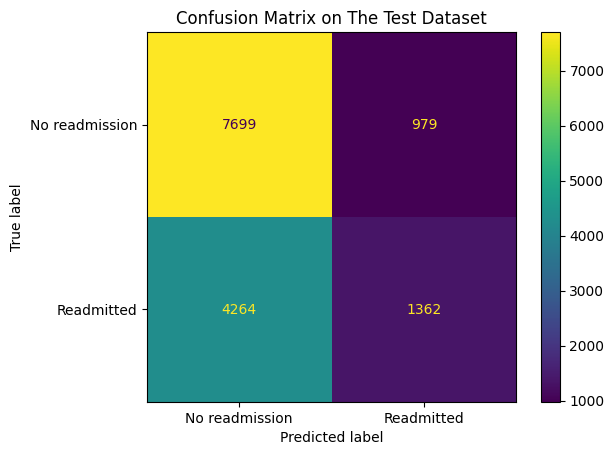

Precisions: 58.18%
False Positives: 979
Recalls: 24.209%
False Negatives: 4264

F1 score: 34.19%


In [7]:
# Calculate the predicted values
Y_train_hat_rf = model_rf.predict(X_train_rf)
Y_test_hat_rf = model_rf.predict(X_test_rf)

# Calculate accuracy values on both train and test datasets
accuracy_train_rf = accuracy_score(Y_train_rf, Y_train_hat_rf)
accuracy_test_rf = accuracy_score(Y_test_rf, Y_test_hat_rf)
print(f"\nThe aggregate accuracy from the training dataset is: {accuracy_train_rf:.2%}")
print(
    f"The aggregate accuracy from the testing dataset is: {accuracy_test_rf:.2%}",
    end="\n\n",
)
print(
    classification_report(
        Y_test_rf, Y_test_hat_rf, target_names=["No readmission", "Readmission"]
    )
)

# Plot the confusion matrix
cm_rf = confusion_matrix(Y_test_rf, Y_test_hat_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["No readmission", "Readmitted"])
disp.plot()
plt.grid(False)  # Hide the white grid lines
plt.title("Confusion Matrix on The Test Dataset")
plt.show()

# Evaluation from the confusion matrix
precision_rf = cm_rf[1][1] / cm_rf[:, 1].sum()
recall_rf = cm_rf[1][1] / cm_rf[1].sum()
print(f"Precisions: {precision_rf:.2%}")
print(f"False Positives: {cm_rf[0][1]}")
print(f"Recalls: {recall_rf:.3%}")
print(f"False Negatives: {cm_rf[1][0]}")
print(f"\nF1 score: {2 * precision_rf * recall_rf / (precision_rf + recall_rf):.2%}")

### 2.2 XGBoost Model

In [8]:
# Make copies from X&Y datasets
X_train_xgb = X_train.copy()
Y_train_xgb = Y_train.copy()
X_val_xgb = X_val.copy()
Y_val_xgb = Y_val.copy()
X_test_xgb = X_test.copy()
Y_test_xgb = Y_test.copy()

# Print the shapes for each dataset
print("(xgb) Shape of X_train: ", X_train_xgb.shape)
print("(xgb) Shape of Y_train: ", Y_train_xgb.shape)
print("(xgb) Shape of X_val: ", X_val_xgb.shape)
print("(xgb) Shape of Y_val: ", Y_val_xgb.shape)
print("(xgb) Shape of X_test: ", X_test_xgb.shape)
print("(xgb) Shape of Y_test: ", Y_test_xgb.shape)

(xgb) Shape of X_train:  (42910, 42)
(xgb) Shape of Y_train:  (42910,)
(xgb) Shape of X_val:  (14304, 42)
(xgb) Shape of Y_val:  (14304,)
(xgb) Shape of X_test:  (14304, 42)
(xgb) Shape of Y_test:  (14304,)


#### 2.2.1 Model development with training and validation datasets

In [9]:
# Hyperparameter Tuning
tuning_options_xgb = {
    "n_estimators": [30, 50, 100, 200, 300, 500],  # Number of boosting rounds
    "max_depth": [3, 6, 8, 12, 16],  # Maximum depth of each tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.4],  # Step size shrinkage
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 3, 5, 7],
}

# Create and fit the model on the training dataset
model_xgb = RandomizedSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        scale_pos_weight=len(Y_train[Y_train == 0]) / len(Y_train[Y_train == 1]),
    ),  # Estimator - XGBoost
    param_distributions=tuning_options_xgb,
    n_iter=30,  # Number of parameter settings sampled
    n_jobs=-1,  # Optimize CPU
    scoring="f1",
)  # Evaluation metric


clf_xgb = model_xgb.fit(X_train_xgb, Y_train_xgb)
print(
    f"Accuracy on the training dataset: {clf_xgb.score(X_train_xgb, Y_train_xgb):.2%}"
)
print(f"Accuracy on the validation dataset: {clf_xgb.score(X_val_xgb, Y_val_xgb):.2%}")

# Obtain the top 5 importance feature names and their importance scores
print("\nTop 5 important features:")
print(
    pd.DataFrame(
        {
            "features": X_train_xgb.columns,
            "importance": clf_xgb.best_estimator_.feature_importances_,
        }
    )
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
    .head()
)

Accuracy on the training dataset: 59.55%
Accuracy on the validation dataset: 53.41%

Top 5 important features:
           features  importance
0  number_inpatient    0.221410
1       diabetesMed    0.058284
2  number_emergency    0.050062
3  number_diagnoses    0.045836
4  race_collapsed_?    0.041320


#### 2.2.2 Model evaluation with training and testing datasets


The aggregate accuracy from the training dataset is: 65.16%
The aggregate accuracy from the testing dataset is: 59.75%

                precision    recall  f1-score   support

No readmission       0.69      0.61      0.65      8678
   Readmission       0.49      0.58      0.53      5626

      accuracy                           0.60     14304
     macro avg       0.59      0.59      0.59     14304
  weighted avg       0.61      0.60      0.60     14304



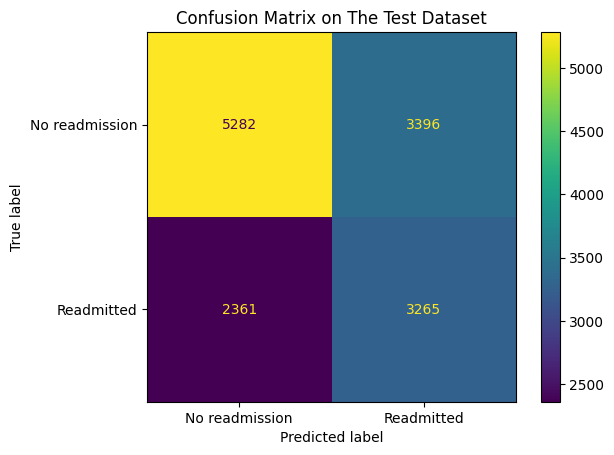

Precisions: 49.02%
False Positives: 3396
Recalls: 58.034%
False Negatives: 2361

F1 score: 53.15%


In [10]:
# Calculate the predicted values
Y_train_hat_xgb = model_xgb.predict(X_train_xgb)
Y_test_hat_xgb = model_xgb.predict(X_test_xgb)

# Calculate accuracy values on both train and test datasets
accuracy_train_xgb = accuracy_score(Y_train_xgb, Y_train_hat_xgb)
accuracy_test_xgb = accuracy_score(Y_test_xgb, Y_test_hat_xgb)
print(
    f"\nThe aggregate accuracy from the training dataset is: {accuracy_train_xgb:.2%}"
)
print(
    f"The aggregate accuracy from the testing dataset is: {accuracy_test_xgb:.2%}",
    end="\n\n",
)
print(
    classification_report(
        Y_test_xgb, Y_test_hat_xgb, target_names=["No readmission", "Readmission"]
    )
)

# Plot the confusion matrix
cm_xgb = confusion_matrix(Y_test_xgb, Y_test_hat_xgb)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=["No readmission", "Readmitted"])
disp.plot()
plt.grid(False)  # Hide the white grid lines
plt.title("Confusion Matrix on The Test Dataset")
plt.show()

# Evaluation from the confusion matrix
precision_xgb = cm_xgb[1][1] / cm_xgb[:, 1].sum()
recall_xgb = cm_xgb[1][1] / cm_xgb[1].sum()
print(f"Precisions: {precision_xgb:.2%}")
print(f"False Positives: {cm_xgb[0][1]}")
print(f"Recalls: {recall_xgb:.3%}")
print(f"False Negatives: {cm_xgb[1][0]}")
print(
    f"\nF1 score: {2 * precision_xgb * recall_xgb / (precision_xgb + recall_xgb):.2%}"
)

## 3. Notebook Exports

#### 3.1 Export models

In [11]:
# Export the random forest and xgboost models into results/
joblib.dump(model_rf, "../results/rf.pkl")
joblib.dump(model_xgb, "../results/xgb.pkl")

['../results/xgb.pkl']

#### 3.2 Export evaluation results

In [12]:
# Initialize the dataframe
stats = pd.DataFrame(
    columns=[
        "feature_importance",
        "precision",
        "recall",
        "false_positive",
        "false_negative",
        "final_accuracy_train",
        "final_accuracy_test",
        "f1",
    ]
)

# Insert model statistics from random forest and xgboost
stats_rf = pd.DataFrame(
    [
        {
            "feature_importance": clf_rf.best_estimator_.feature_importances_,  # Force importance values to be included in one row
            "precision": precision_rf,
            "recall": recall_rf,
            "false_positive": cm_rf[0][1],
            "false_negative": cm_rf[1][0],
            "final_accuracy_train": accuracy_score(Y_train_rf, Y_train_hat_rf),
            "final_accuracy_test": accuracy_score(Y_test_rf, Y_test_hat_rf),
            "f1": 2 * precision_rf * recall_rf / (precision_rf + recall_rf),
        }
    ]
)
stats_xgb = pd.DataFrame(
    [
        {
            "feature_importance": clf_xgb.best_estimator_.feature_importances_,  # Force importance values to be included in one row
            "precision": precision_xgb,
            "recall": recall_xgb,
            "false_positive": cm_xgb[0][1],
            "false_negative": cm_xgb[1][0],
            "final_accuracy_train": accuracy_score(Y_train_xgb, Y_train_hat_xgb),
            "final_accuracy_test": accuracy_score(Y_test_xgb, Y_test_hat_xgb),
            "f1": 2 * precision_xgb * recall_xgb / (precision_xgb + recall_xgb),
        }
    ]
)

# Combine the stats and export as csv
stats = pd.concat([stats, stats_rf, stats_xgb], ignore_index=True)
stats.to_csv("../results/stats_rf_xgb.csv", index=False)